In [102]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred)
    }


In [ ]:

# Load the merged dataset
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_state_IX_norm.csv')

state_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9}
df['state'] = df['state'].map(state_map)
train_groups = [(25, 6), (25, 7), (25, 8), (25, 5), (25, 3), (25, 4), (35, 1), (25, 2), (45, 2)]
test_groups  = [(25, 1), (35, 2), (45, 1)]         # final test cell(s)

In [104]:
def mask_from_groups(df, groups):
    groups = set(groups)
    return df.apply(lambda r: (r["T_C"], r["cell"]) in groups, axis=1)

train_mask = mask_from_groups(df, train_groups)
test_mask  = mask_from_groups(df, test_groups)

train_df = df[train_mask].copy()
test_df  = df[test_mask].copy()

print("Train:", train_df.shape, "Groups:", sorted(set(zip(train_df.T_C, train_df.cell))))
print("Test :", test_df.shape,  "Groups:", sorted(set(zip(test_df.T_C, test_df.cell))))

Train: (1770, 31) Groups: [(25, 2), (25, 3), (25, 4), (25, 5), (25, 6), (25, 7), (25, 8), (35, 1), (45, 2)]
Test : (966, 31) Groups: [(25, 1), (35, 2), (45, 1)]


In [105]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

features = [
    "R_s_rel",
    "R_ct_rel",
    "R_sei_rel",
    "Zmag_0.1Hz_rel",
    "C_dl_log",
    "tail_slope","Zmag_1000Hz_rel",
    "T_C"
]

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MSE": mean_squared_error(y_true, y_pred)
    }

X_train, y_train = train_df[features], train_df["SOH"]
#X_val,   y_val   = val_df[features],   val_df["SOH"]
X_test,  y_test  = test_df[features],  test_df["SOH"]

print("NaNs train:", X_train.isna().sum().sum(), "test:", X_test.isna().sum().sum())


NaNs train: 0 test: 0


In [ ]:
features = [
    "R_s_rel",
    "R_ct_rel",
    "R_sei_rel",
    "Zmag_0.1Hz_rel",
    "C_dl_log",
    "tail_slope","Zmag_1000Hz_rel",
    "T_C"
]

X_train, y_train = train_df[features], train_df["SOH"]
#X_val,   y_val   = val_df[features],   val_df["SOH"]
X_test,  y_test  = test_df[features],  test_df["SOH"]

from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="median")
X_train[:] = imp.fit_transform(X_train)
X_test[:]  = imp.transform(X_test)
print("NaNs train:", X_train.isna().sum().sum(), '"val:", X_val.isna().sum().sum(),' "test:", X_test.isna().sum().sum())


NaNs train: 0 "val:", X_val.isna().sum().sum(),test: 0


/var/folders/2t/k392bwxd4tb6pyly82dg4pqw0000gn/T/ipykernel_1445/3725671243.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[:] = imp.fit_transform(X_train)
/var/folders/2t/k392bwxd4tb6pyly82dg4pqw0000gn/T/ipykernel_1445/3725671243.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[:]  = imp.transform(X_test)


Random forest

In [107]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt",
    min_samples_leaf=1
)

rf_base.fit(X_train, y_train)
rf_base.fit(X_train, y_train)
print("RF TEST:", metrics(y_test, rf_base.predict(X_test)))

print("Base RF")
#print("Train:", metrics(y_train, rf_base.predict(X_train)))
#print("Test :", metrics(y_test,  rf_base.predict(X_test)))

RF TEST: {'R2': 0.8955195004457781, 'MAE': 0.0485307842142365, 'RMSE': 0.058689153382905083, 'MSE': 0.0034444167248021593}
Base RF


XgBoost

In [ ]:
import numpy as np
from xgboost import XGBRegressor



xgb_stack = XGBRegressor(
    n_estimators=8000,
    learning_rate=0.08,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=0.7,
    reg_lambda=0.5,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror",
    eval_metric="rmse"
)
xgb_stack.fit(X_train, y_train)
print("XGB TEST:", metrics(y_test, xgb_stack.predict(X_test)))




XGB TEST: {'R2': 0.8696147884407313, 'MAE': 0.04972599613031385, 'RMSE': 0.06556233196569602, 'MSE': 0.004298419372780127}


LightGBM

In [109]:
import lightgbm as lgb

force_col_wise=True

lgbm = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=-1,          # -1 = no limit
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    min_child_samples=50,
    random_state=42,
    n_jobs=-1,
    #force_col_wise=true
)
lgbm.fit(X_train, y_train)
print("LGBM TEST:", metrics(y_test, lgbm.predict(X_test)))



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1770, number of used features: 8
[LightGBM] [Info] Start training from score 0.730683
LGBM TEST: {'R2': 0.8539953426742571, 'MAE': 0.04881568730676375, 'RMSE': 0.06937828804233398, 'MSE': 0.0048133468516850615}


CatBoost

In [110]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_seed=42
)

cat.fit(X_train, y_train)

print("Train:", metrics(y_train, cat.predict(X_train)))
#print("Val  :", metrics(y_val,   cat.predict(X_val)))
print("Test :", metrics(y_test,  cat.predict(X_test)))

Train: {'R2': 0.9991527766893136, 'MAE': 0.003914270672870622, 'RMSE': 0.00517756591891994, 'MSE': 2.6807188844761286e-05}
Test : {'R2': 0.889995898175617, 'MAE': 0.04509748708282488, 'RMSE': 0.060220542581881045, 'MSE': 0.0036265137488561486}


In [121]:
base_models = {
    "rf": rf_base,
    "xgb": xgb_stack,
    "lgb": lgbm,
    #"cb": cat
}


groupkfold

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.base import clone

def get_oof_predictions_group(models, X, y, X_test, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)

    oof_train = pd.DataFrame(index=X.index)
    oof_test  = pd.DataFrame(index=X_test.index)

    for name, model in models.items():
        oof_pred = np.zeros(len(X))
        test_pred_folds = np.zeros((len(X_test), n_splits))

        for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

            m = clone(model)
            m.fit(X_tr, y_tr)

            oof_pred[val_idx] = m.predict(X_val)
            test_pred_folds[:, fold] = m.predict(X_test)

        oof_train[name] = oof_pred
        oof_test[name]  = test_pred_folds.mean(axis=1)

        print(f"{name} GROUP-OOF metrics:", metrics(y, oof_train[name].values))

    return oof_train, oof_test
# 1) Build groups using (cell, T_C) combo
groups = df.loc[X_train.index, ["cell", "T_C"]].astype(str).agg("_".join, axis=1)

# 2) Keep T_C as feature, but drop cell from features
X_train_feat = X_train.drop(columns=["cell"]) if "cell" in X_train.columns else X_train
X_test_feat  = X_test.drop(columns=["cell"])  if "cell" in X_test.columns else X_test


oof_train, oof_test = get_oof_predictions_group(
    base_models, X_train_feat, y_train, X_test_feat,
    groups=groups, n_splits=5
)




rf GROUP-OOF metrics: {'R2': 0.5222224716342957, 'MAE': 0.08662381264750428, 'RMSE': 0.12295311848909861, 'MSE': 0.015117469346194323}
xgb GROUP-OOF metrics: {'R2': 0.4542761871070763, 'MAE': 0.09871427675478381, 'RMSE': 0.13140537835113064, 'MSE': 0.01726737345960379}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000180 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1443, number of used features: 8
[LightGBM] [Info] Start training from score 0.768284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1788
[LightGBM] [Info] Number of data points in the train set: 1409, number of used features: 8
[LightGBM] [Info] Start training from score 0.724022
[LightGBM] [Info] Auto-choosing col-wise multi-thr

meta model- Linear Regreesion

In [123]:
from sklearn.linear_model import LinearRegression

meta_pos = LinearRegression(positive=True)
meta_pos.fit(oof_train, y_train)
stack_pred = meta_pos.predict(oof_test)

print("Stack (positive LR):", metrics(y_test, stack_pred))
print(pd.Series(meta_pos.coef_, index=oof_train.columns))


Stack (positive LR): {'R2': 0.9049656347633585, 'MAE': 0.04620672870861961, 'RMSE': 0.05597325506696247, 'MSE': 0.0031330052827912395}
rf     0.573038
xgb    0.055085
lgb    0.401513
dtype: float64


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_nnls.py:164: RuntimeWarning: divide by zero encountered in matmul
  return x, np.linalg.norm(A@x - b), 1
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_nnls.py:164: RuntimeWarning: overflow encountered in matmul
  return x, np.linalg.norm(A@x - b), 1
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_nnls.py:164: RuntimeWarning: invalid value encountered in matmul
  return x, np.linalg.norm(A@x - b), 1
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/

In [124]:
meta_model = Ridge(alpha=1.0, random_state=42)
meta_model.fit(oof_train, y_train)

stack_pred_r = meta_model.predict(oof_test)
print("STACKED TEST:", metrics(y_test, stack_pred_r))


STACKED TEST: {'R2': 0.9122913824944513, 'MAE': 0.043986134846530654, 'RMSE': 0.053772639787180235, 'MSE': 0.0028914967896818385}


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [96]:
# Fit each base model on full train and evaluate on test
for name, model in base_models.items():
    m = clone(model)
    m.fit(X_train_feat, y_train)
    pred = m.predict(X_test_feat)
    print(name, "TEST:", metrics(y_test, pred))


rf TEST: {'R2': 0.8955195004457781, 'MAE': 0.04853078421423649, 'RMSE': 0.05868915338290508, 'MSE': 0.003444416724802158}
xgb TEST: {'R2': 0.8696147884407313, 'MAE': 0.04972599613031385, 'RMSE': 0.06556233196569602, 'MSE': 0.004298419372780127}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1770, number of used features: 8
[LightGBM] [Info] Start training from score 0.730683
lgb TEST: {'R2': 0.8539953426742571, 'MAE': 0.04881568730676375, 'RMSE': 0.06937828804233398, 'MSE': 0.0048133468516850615}


confidence interval

In [115]:
import numpy as np

def bootstrap_ci(y_true, y_pred, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        score = r2_score(y_true.iloc[idx], y_pred[idx])
        scores.append(score)

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    return np.mean(scores), lower, upper

mean_r2, low, high = bootstrap_ci(y_test, stack_pred_r)

print(f"Stack R² mean: {mean_r2:.4f}")
print(f"95% CI: [{low:.4f}, {high:.4f}]")


Stack R² mean: 0.9120
95% CI: [0.9010, 0.9218]


In [98]:
from sklearn.base import clone

test_preds = {}

for name, model in base_models.items():
    m = clone(model)
    m.fit(X_train_feat, y_train)
    test_preds[name] = m.predict(X_test_feat)

print("Saved predictions for:", list(test_preds.keys()))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1770, number of used features: 8
[LightGBM] [Info] Start training from score 0.730683
Saved predictions for: ['rf', 'xgb', 'lgb']


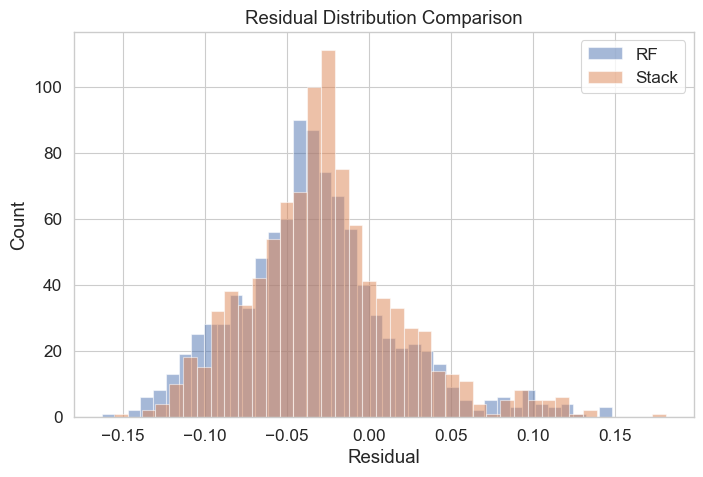

In [139]:
import matplotlib.pyplot as plt

rf_pred = test_preds["rf"]

rf_res = y_test - rf_pred
stack_res = y_test - stack_pred_r

plt.figure(figsize=(8,5))
plt.hist(rf_res, bins=40, alpha=0.5, label="RF")
plt.hist(stack_res, bins=40, alpha=0.5, label="Stack")
plt.legend()
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution Comparison")
plt.show()


In [24]:
import pandas as pd

results_table = pd.DataFrame({
    "Model": ["RF", "XGB", "LGB", "CB", "Stack"],
    "R2": [
        0.8955,
        0.8696,
        0.8540,
        0.8900,
        0.9050
    ]
})

results_table.sort_values("R2", ascending=False)


,Model,R2
4,Stack,0.9050
0,RF,0.8955
3,CB,0.8900
1,XGB,0.8696
2,LGB,0.8540


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


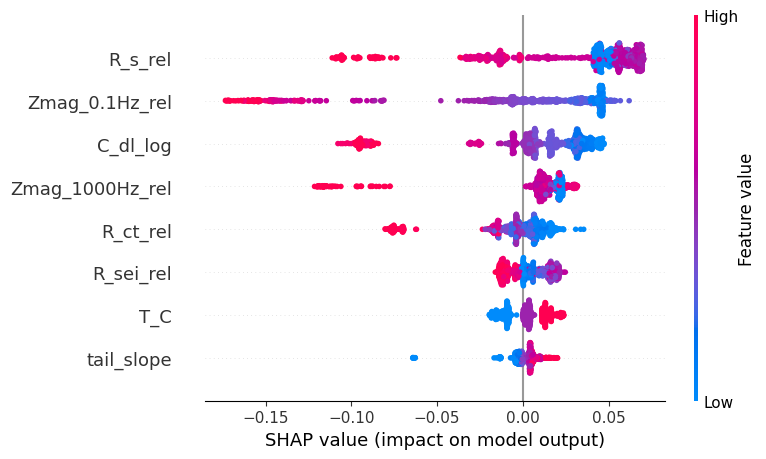

In [25]:
import shap

explainer = shap.TreeExplainer(rf_base)
shap_values = explainer.shap_values(X_test_feat)

shap.summary_plot(shap_values, X_test_feat)


In [125]:
meta_shap = meta_pos.coef_
print(pd.Series(meta_shap, index=oof_train.columns))


rf     0.573038
xgb    0.055085
lgb    0.401513
dtype: float64


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone
import numpy as np

feature_cols = [c for c in df.columns if c not in ["SOH", "cell"]]
X_full = df[feature_cols]
y_full = df["SOH"]

#  Build groups (cell + temperature combo) 
groups_full = df[["cell", "T_C"]].astype(str).agg("_".join, axis=1)

gss = GroupShuffleSplit(n_splits=5, test_size=0.3, random_state=42)

all_scores = []

for train_idx, test_idx in gss.split(X_full, y_full, groups=groups_full):

    X_tr, X_te = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_tr, y_te = y_full.iloc[train_idx], y_full.iloc[test_idx]

    m = clone(rf_base) 
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)

    score = r2_score(y_te, pred)
    all_scores.append(score)

print("Mean R²:", np.mean(all_scores))
print("Std R² :", np.std(all_scores))


Mean R²: 0.6907343988880058
Std R² : 0.19961898306878303


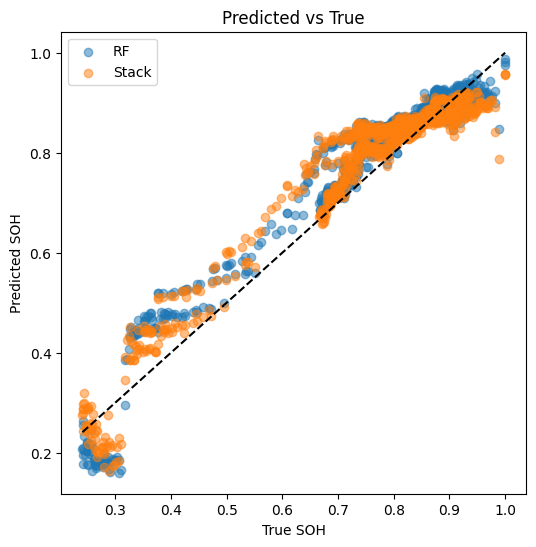

In [29]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, test_preds["rf"], alpha=0.5, label="RF")
plt.scatter(y_test, stack_pred, alpha=0.5, label="Stack")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--')

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.legend()
plt.title("Predicted vs True")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set(style="whitegrid", context="paper", font_scale=1.4)

def plot_soh(y_true, y_pred, model_name):
    
    plt.figure(figsize=(6,6))
    
    # Scatter plot
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, edgecolor=None)
    
    # Ideal line
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', linewidth=1.5, label="Ideal")

    # Regression line
    sns.regplot(x=y_true, y=y_pred, scatter=False, color="black")

    # Metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mse = mean_squared_error(y_true, y_pred)

    # Metrics box
    plt.text(0.05, 0.95,
             f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}\nRMSE = {rmse:.3f}\nMSE = {mse:.3f}",
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

    # Labels
    plt.xlabel("True SOH")
    plt.ylabel("Predicted SOH")
    plt.title(f"{model_name}: Predicted vs True SOH")
    plt.legend()

    plt.tight_layout()
    plt.show()

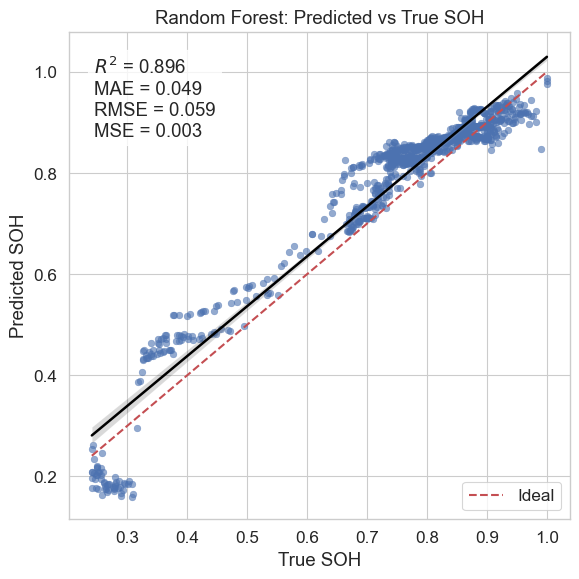

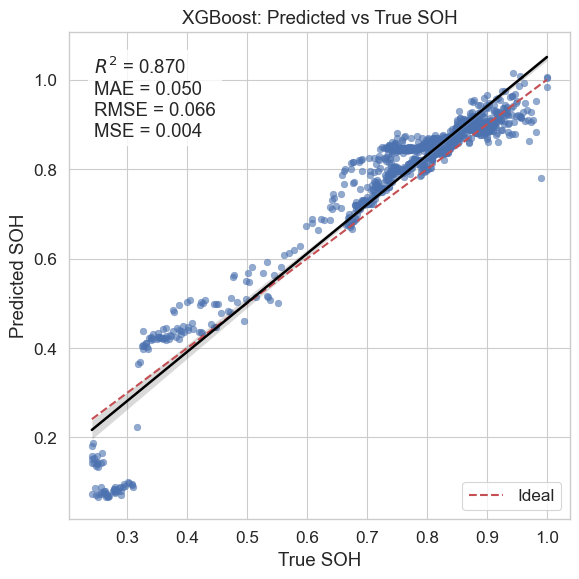

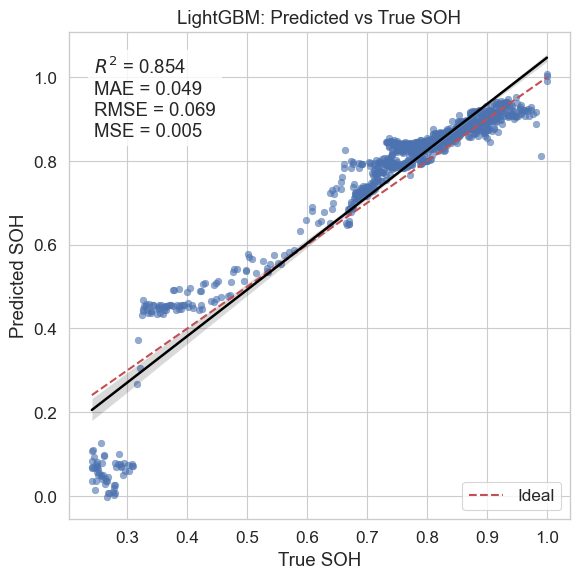

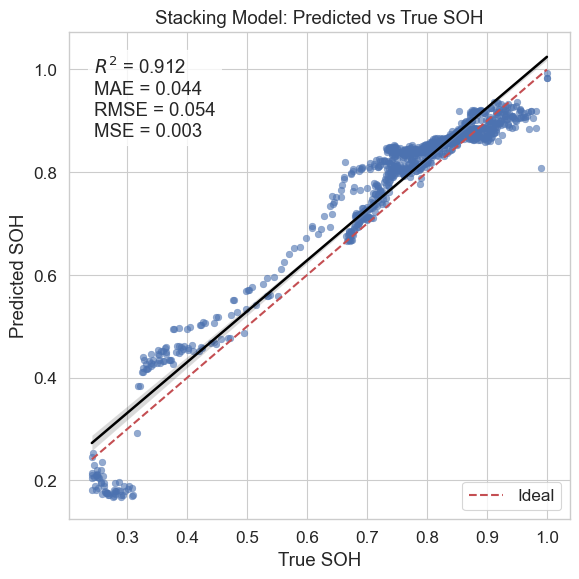

In [127]:
plot_soh(y_test, test_preds["rf"], "Random Forest")
plot_soh(y_test, test_preds["xgb"], "XGBoost")
plot_soh(y_test, test_preds["lgb"], "LightGBM")
#plot_soh(y_test, test_preds["cb"], "CatBoost")
plot_soh(y_test, stack_pred_r, "Stacking Model")

 

In [ ]:
cv_preds = {}

for name in base_models.keys():
    cv_preds[name] = oof_train[name].values


In [134]:
from sklearn.metrics import r2_score

def plot_pred_vs_true(y_true, y_pred, title):
    r2 = r2_score(y_true, y_pred)
    
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    
    plt.plot([min_val, max_val],
             [min_val, max_val],
             'k--', linewidth=1)
    
    plt.xlabel("True SOH")
    plt.ylabel("Predicted SOH")
    plt.title(f"{title}\nR² = {r2:.3f}")
    plt.tight_layout()
    plt.show()



In [ ]:
for name in base_models.keys():
    plot_pred_vs_true(
        y_train,
        cv_preds[name],
        title=f"{name.upper()} - Group CV (OOF)"
    )


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
    }

#  Building groups for TRAIN only (cell + temp combo) 
groups_train = df.loc[X_train.index, ["cell", "T_C"]].astype(str).agg("_".join, axis=1)

# Use features selected (drop cell ID if it exists in X matrices)
X_train_feat = X_train.drop(columns=["cell"]) if "cell" in X_train.columns else X_train
X_test_feat  = X_test.drop(columns=["cell"])  if "cell" in X_test.columns else X_test


def evaluate_model_groupcv_and_test(model, X_train, y_train, groups_train, X_test, y_test, n_splits=5):
    n_splits = min(n_splits, pd.Series(groups_train).nunique())
    gkf = GroupKFold(n_splits=n_splits)

    oof_pred = np.zeros(len(X_train))

    #  GroupCV (validation) on TRAIN only
    for tr_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
        m = clone(model)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        oof_pred[val_idx] = m.predict(X_train.iloc[val_idx])

    cv_scores = metrics(y_train, oof_pred)

    # Final model trained on ALL TRAIN, evaluated on TEST
    m_full = clone(model)
    m_full.fit(X_train, y_train)
    test_pred = m_full.predict(X_test)

    test_scores = metrics(y_test, test_pred)

    return cv_scores, test_scores, test_pred


In [34]:
results = []
test_preds_single = {}

for name, model in base_models.items():
    cv_scores, test_scores, test_pred = evaluate_model_groupcv_and_test(
        model,
        X_train_feat, y_train,
        groups_train,
        X_test_feat, y_test,
        n_splits=5
    )

    results.append({
        "model": name,
        "CV_R2": cv_scores["R2"],
        "CV_RMSE": cv_scores["RMSE"],
        "CV_MSE": cv_scores["MSE"],
        "CV_MAE": cv_scores["MAE"],
        "TEST_R2": test_scores["R2"],
        "TEST_RMSE": test_scores["RMSE"],
        "TEST_MSE": test_scores["MSE"],
        "TEST_MAE": test_scores["MAE"],
    })

    test_preds_single[name] = test_pred

results_df = pd.DataFrame(results).sort_values("TEST_R2", ascending=False)
results_df


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1443, number of used features: 8
[LightGBM] [Info] Start training from score 0.768284
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1788
[LightGBM] [Info] Number of data points in the train set: 1409, number of used features: 8
[LightGBM] [Info] Start training from score 0.724022
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1788
[LightGBM] [Info] Number of data points in the train set: 1423, number of used features: 8
[LightGBM] [Info] Start training 

,model,CV_R2,CV_RMSE,CV_MSE,CV_MAE,TEST_R2,TEST_RMSE,TEST_MSE,TEST_MAE
0,rf,0.522222,0.122953,0.015117,0.086624,0.895520,0.058689,0.003444,0.048531
3,cb,0.404940,0.137217,0.018828,0.088399,0.889996,0.060221,0.003627,0.045097
1,xgb,0.454276,0.131405,0.017267,0.098714,0.869615,0.065562,0.004298,0.049726
2,lgb,0.521976,0.122985,0.015125,0.091174,0.853995,0.069378,0.004813,0.048816


In [ ]:
from sklearn.base import clone

train_preds_single = {}

for name, model in base_models.items():
    m = clone(model)
    m.fit(X_train_feat, y_train)
    train_preds_single[name] = m.predict(X_train_feat)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1789
[LightGBM] [Info] Number of data points in the train set: 1770, number of used features: 8
[LightGBM] [Info] Start training from score 0.730683


In [ ]:
# stacking train prediction
meta_model.fit(oof_train, y_train)
stack_train_pred = meta_model.predict(oof_train)


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [ ]:
import matplotlib.pyplot as plt

def plot_all_sets(y_train, y_train_pred,
                  y_cv_pred,
                  y_test, y_test_pred,
                  title):

    plt.figure(figsize=(6,6))

    # Train
    plt.scatter(y_train, y_train_pred, alpha=0.3, label="Train")

    # CV (OOF) 
    if y_cv_pred is not None:
        plt.scatter(y_train, y_cv_pred, alpha=0.5, label="Group-CV")

    # Test
    plt.scatter(y_test, y_test_pred, alpha=0.7, label="Test")

    # Diagonal reference line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1)

    plt.xlabel("True SOH")
    plt.ylabel("Predicted SOH")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
stack_cv_pred = meta_model.predict(oof_train)


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


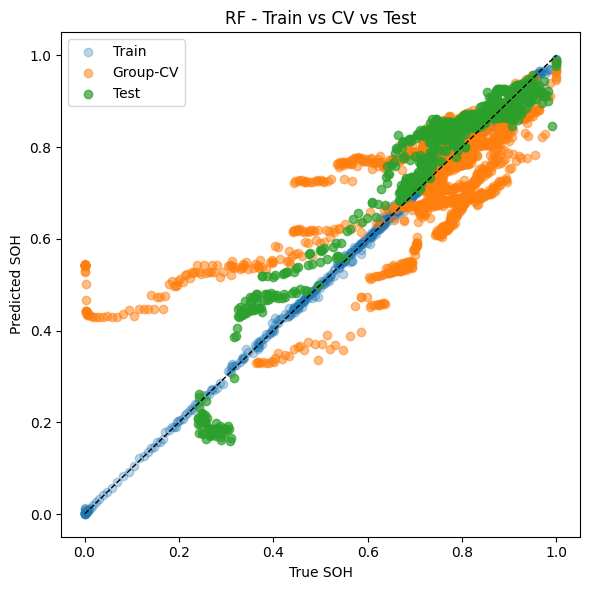

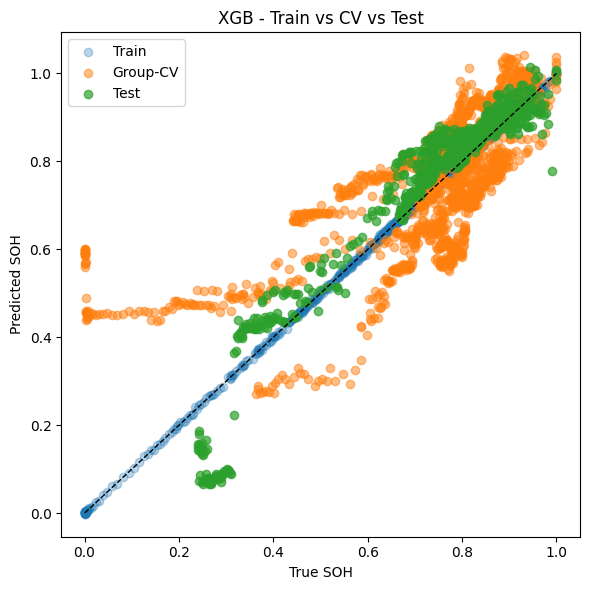

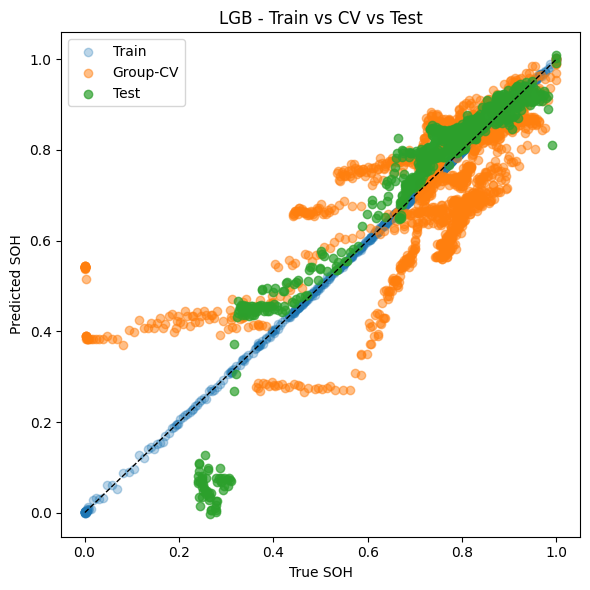

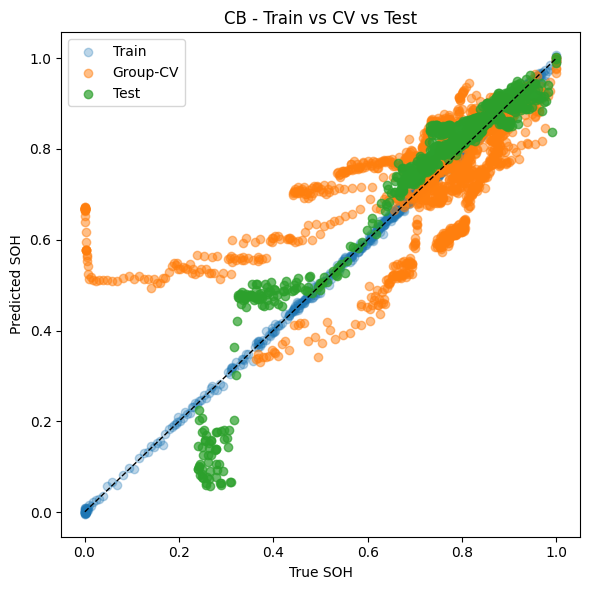

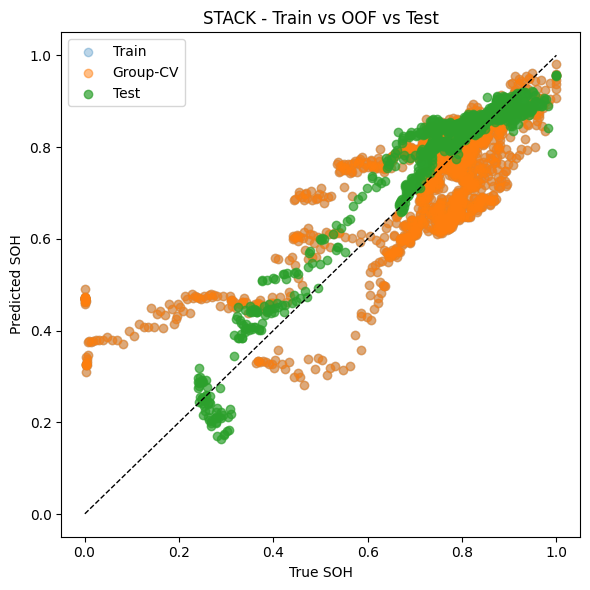

In [ ]:
for name in base_models.keys():
    plot_all_sets(
        y_train,
        train_preds_single[name],
        cv_preds[name],
        y_test,
        test_preds_single[name],
        title=f"{name.upper()} - Train vs CV vs Test"
    )


plot_all_sets(
    y_train,
    stack_train_pred,
    stack_cv_pred,
    y_test,
    stack_pred,
    title="STACK - Train vs OOF vs Test"
)



Stacking test metrics:
{'R2': 0.9122913824944513, 'MAE': 0.043986134846530654, 'RMSE': np.float64(0.053772639787180235), 'MSE': 0.0028914967896818385}


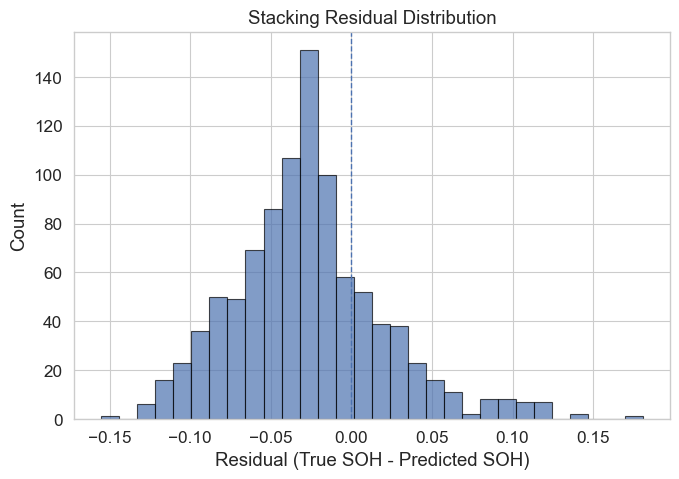

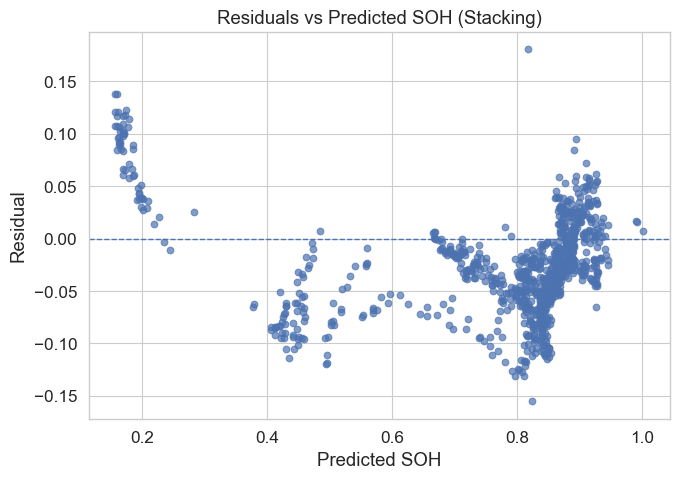

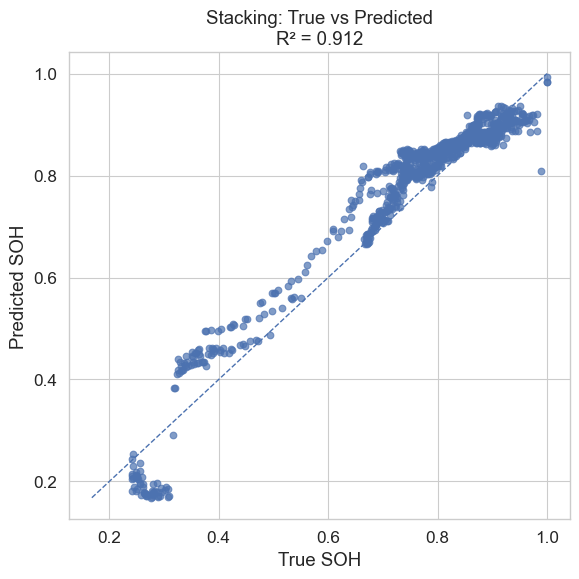


Bootstrap 95% Confidence Intervals for Stacking:
R2: mean=0.9119, 95% CI=(0.9004, 0.9219)
MAE: mean=0.0440, 95% CI=(0.0419, 0.0459)
RMSE: mean=0.0537, 95% CI=(0.0515, 0.0559)


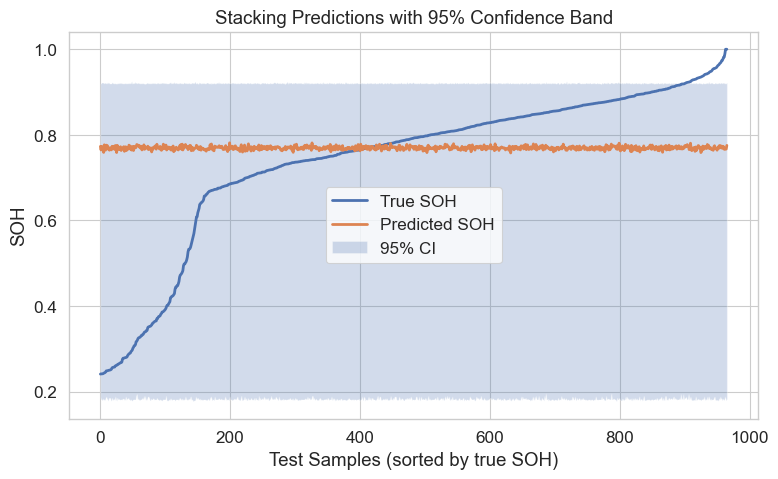

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) Basic metrics
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
    }

print("Stacking test metrics:")
print(regression_metrics(y_test, stack_pred_r))

# 2) Residuals
residuals = y_test - stack_pred_r

# Plot A: Residual histogram
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Residual (True SOH - Predicted SOH)")
plt.ylabel("Count")
plt.title("Stacking Residual Distribution")
plt.tight_layout()
plt.show()

# Plot B: Residuals vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(stack_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Predicted SOH")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted SOH (Stacking)")
plt.tight_layout()
plt.show()

# Plot C: True vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, stack_pred_r, alpha=0.7)

min_val = min(np.min(y_test), np.min(stack_pred_r))
max_val = max(np.max(y_test), np.max(stack_pred_r))

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)
plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title(f"Stacking: True vs Predicted\nR² = {r2_score(y_test, stack_pred_r):.3f}")
plt.tight_layout()
plt.show()

# 3) Bootstrap confidence interval for metrics
def bootstrap_metric_ci(y_true, y_pred, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    r2_list, mae_list, rmse_list = [], [], []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt = y_true[idx]
        yp = y_pred[idx]

        r2_list.append(r2_score(yt, yp))
        mae_list.append(mean_absolute_error(yt, yp))
        rmse_list.append(np.sqrt(mean_squared_error(yt, yp)))

    def ci(arr):
        return np.mean(arr), np.percentile(arr, 2.5), np.percentile(arr, 97.5)

    return {
        "R2": ci(r2_list),
        "MAE": ci(mae_list),
        "RMSE": ci(rmse_list),
    }

ci_results = bootstrap_metric_ci(y_test, stack_pred_r, n_boot=2000)

print("\nBootstrap 95% Confidence Intervals for Stacking:")
for metric, (mean_val, low, high) in ci_results.items():
    print(f"{metric}: mean={mean_val:.4f}, 95% CI=({low:.4f}, {high:.4f})")

# 4) Pointwise confidence band around predictions using bootstrap resampling   

def bootstrap_prediction_band(y_true, y_pred, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    pred_samples = np.zeros((n_boot, n))

    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        pred_samples[i] = y_pred[idx]

    pred_mean = np.mean(pred_samples, axis=0)
    pred_low = np.percentile(pred_samples, 2.5, axis=0)
    pred_high = np.percentile(pred_samples, 97.5, axis=0)

    return pred_mean, pred_low, pred_high

pred_mean, pred_low, pred_high = bootstrap_prediction_band(y_test, stack_pred_r)

# Sort by true SOH for cleaner plotting
order = np.argsort(y_test)

y_test_sorted = np.asarray(y_test)[order]
pred_mean_sorted = pred_mean[order]
pred_low_sorted = pred_low[order]
pred_high_sorted = pred_high[order]

plt.figure(figsize=(8,5))
plt.plot(y_test_sorted, label="True SOH", linewidth=2)
plt.plot(pred_mean_sorted, label="Predicted SOH", linewidth=2)
plt.fill_between(
    np.arange(len(y_test_sorted)),
    pred_low_sorted,
    pred_high_sorted,
    alpha=0.25,
    label="95% CI"
)

plt.xlabel("Test Samples (sorted by true SOH)")
plt.ylabel("SOH")
plt.title("Stacking Predictions with 95% Confidence Band")
plt.legend()
plt.tight_layout()
plt.show()

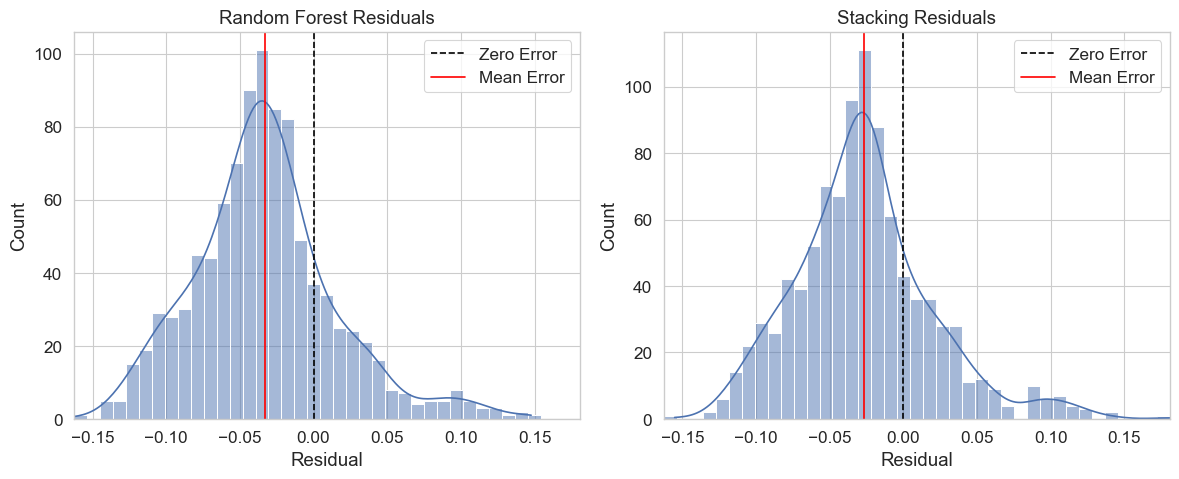

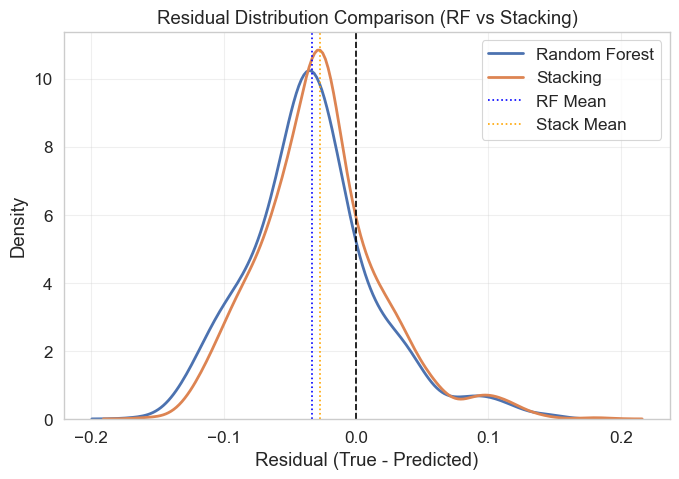

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

rf_residuals = y_test - rf_pred
stack_residuals = y_test - stack_pred_r

# Common axis limits
min_res = min(rf_residuals.min(), stack_residuals.min())
max_res = max(rf_residuals.max(), stack_residuals.max())

# Same bins
bins = np.linspace(min_res, max_res, 40)

plt.figure(figsize=(12,5))

#  RF
plt.subplot(1,2,1)
sns.histplot(rf_residuals, bins=bins, kde=True)

plt.axvline(0, linestyle="--", color="black", label="Zero Error")
plt.axvline(np.mean(rf_residuals), color="red", label="Mean Error")

plt.title("Random Forest Residuals")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.xlim(min_res, max_res)
plt.legend()

# STACK 
plt.subplot(1,2,2)
sns.histplot(stack_residuals, bins=bins, kde=True)

plt.axvline(0, linestyle="--", color="black", label="Zero Error")
plt.axvline(np.mean(stack_residuals), color="red", label="Mean Error")

plt.title("Stacking Residuals")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.xlim(min_res, max_res)
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))

# KDE curves 
sns.kdeplot(rf_residuals, label="Random Forest", linewidth=2)
sns.kdeplot(stack_residuals, label="Stacking", linewidth=2)

# Zero line
plt.axvline(0, linestyle="--", color="black")

# Mean lines
plt.axvline(np.mean(rf_residuals), color="blue", linestyle=":", label="RF Mean")
plt.axvline(np.mean(stack_residuals), color="orange", linestyle=":", label="Stack Mean")

plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Density")
plt.title("Residual Distribution Comparison (RF vs Stacking)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

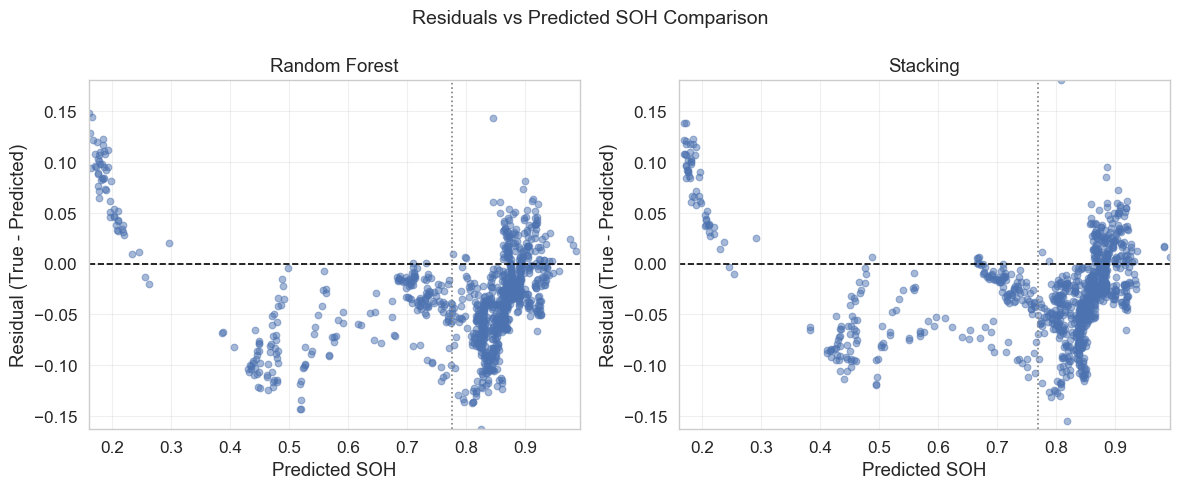

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Predictions
rf_pred = rf_base.predict(X_test)
stack_pred = stack_pred_r 

# Residuals
rf_residuals = y_test - rf_pred
stack_residuals = y_test - stack_pred_r

# Common axis limits
x_min = min(rf_pred.min(), stack_pred.min())
x_max = max(rf_pred.max(), stack_pred.max())

y_min = min(rf_residuals.min(), stack_residuals.min())
y_max = max(rf_residuals.max(), stack_residuals.max())

plt.figure(figsize=(12,5))

#  Random Forest 
plt.subplot(1,2,1)
plt.scatter(rf_pred, rf_residuals, alpha=0.5)

plt.axhline(0, linestyle="--", color="black")
plt.axvline(np.mean(rf_pred), linestyle=":", color="gray")

plt.xlabel("Predicted SOH")
plt.ylabel("Residual (True - Predicted)")
plt.title("Random Forest")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(alpha=0.3)

# STACK 
plt.subplot(1,2,2)
plt.scatter(stack_pred, stack_residuals, alpha=0.5)

plt.axhline(0, linestyle="--", color="black")
plt.axvline(np.mean(stack_pred), linestyle=":", color="gray")

plt.xlabel("Predicted SOH")
plt.ylabel("Residual (True - Predicted)")
plt.title("Stacking")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(alpha=0.3)

plt.suptitle("Residuals vs Predicted SOH Comparison", fontsize=14)
plt.tight_layout()
plt.show()

/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Decisio

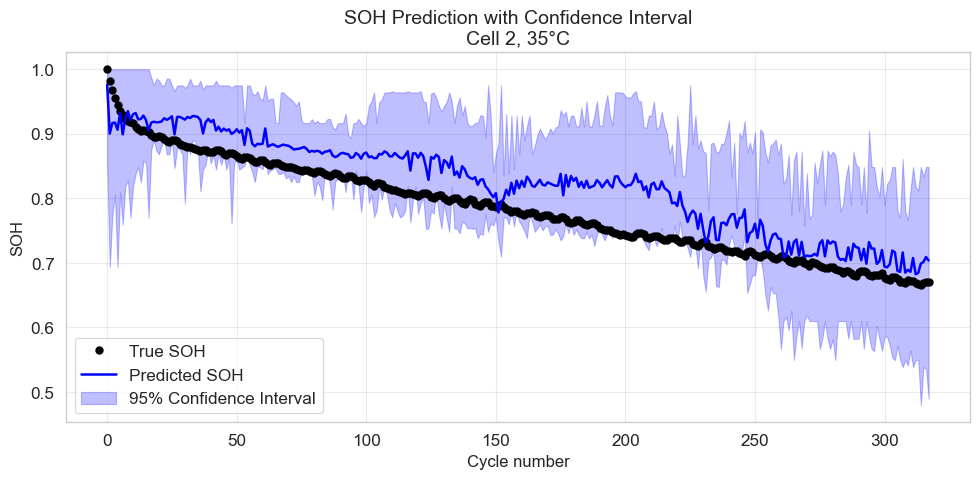

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) GET MEAN PREDICTION + CONFIDENCE INTERVAL FROM RF

# Predictions from each tree
tree_preds = np.array([tree.predict(X_test) for tree in rf_base.estimators_])

# Mean prediction
y_pred_mean = tree_preds.mean(axis=0)

# 95% confidence interval from tree spread
lower = np.percentile(tree_preds, 2.5, axis=0)
upper = np.percentile(tree_preds, 97.5, axis=0)

# Adding predictions into plotting dataframe
plot_df = test_df.copy().reset_index(drop=True)
plot_df["SOH_pred"] = y_pred_mean
plot_df["SOH_lower"] = lower
plot_df["SOH_upper"] = upper

# 2) SELECT CELL + TEMPERATURE TO PLOT
cell_id = 2
temp = 35

df_plot = plot_df[
    (plot_df["cell"] == cell_id) &
    (plot_df["T_C"] == temp)
].sort_values("cycle")

# 3) PLOT
plt.figure(figsize=(10, 5))

# True SOH
plt.plot(
    df_plot["cycle"],
    df_plot["SOH"],
    'o',
    color="black",
    markersize=5,
    label="True SOH"
)

# Predicted SOH
plt.plot(
    df_plot["cycle"],
    df_plot["SOH_pred"],
    color="blue",
    linewidth=1.8,
    label="Predicted SOH"
)

# Confidence interval band
plt.fill_between(
    df_plot["cycle"],
    df_plot["SOH_lower"],
    df_plot["SOH_upper"],
    color="blue",
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title(f"SOH Prediction with Confidence Interval\nCell {cell_id}, {temp}°C", fontsize=14)
plt.xlabel("Cycle number", fontsize=12)
plt.ylabel("SOH", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Make sure X_train and X_test are DataFrames with feature names   

if not isinstance(X_train, pd.DataFrame):
    X_train_df = pd.DataFrame(X_train)
else:
    X_train_df = X_train.copy()

if not isinstance(X_test, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test)
else:
    X_test_df = X_test.copy()

# 2. Use a smaller background sample
background = shap.sample(X_train_df, 100, random_state=42)
test_sample = shap.sample(X_test_df, min(200, len(X_test_df)), random_state=42)

# 3. Create SHAP explainer for stacking model

explainer = shap.Explainer(stack_pred_r.predict, background)
shap_values = explainer(test_sample)

# 4. Summary plot (beeswarm)
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()

# 5. Bar plot of feature importance
plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()

# 6. Optional: dependence plot for one feature
feature_to_plot = test_sample.columns[0]

shap.plots.scatter(shap_values[:, feature_to_plot], show=False)
plt.tight_layout()
plt.show()

# 7. Optional: save mean absolute SHAP values in a table
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": test_sample.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False)

print(shap_importance_df.head(20))

AttributeError: 'numpy.ndarray' object has no attribute 'predict'

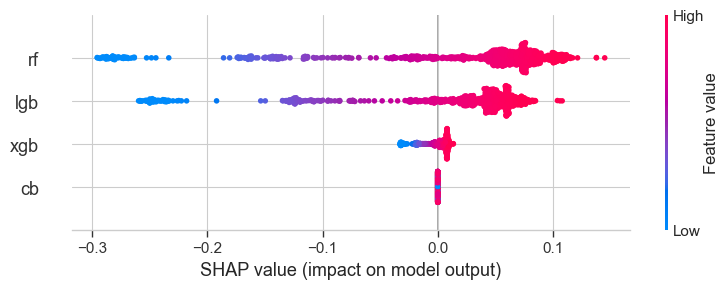

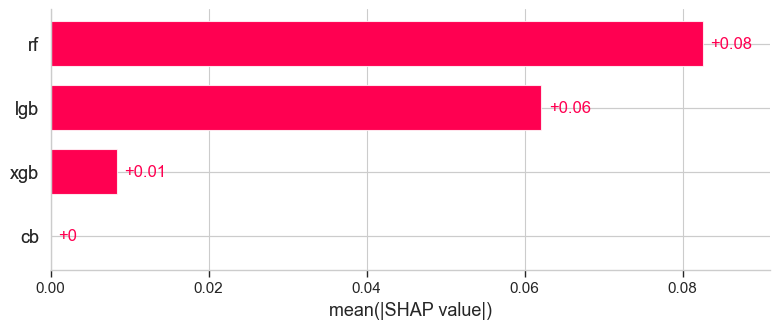

  Base_Model  MeanAbsSHAP  Coefficient
0         rf     0.082551     0.573038
2        lgb     0.062084     0.401513
1        xgb     0.008388     0.055085
3         cb     0.000000     0.000000


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Making sure oof_train and oof_test are DataFrames
if not isinstance(oof_train, pd.DataFrame):
    oof_train = pd.DataFrame(oof_train)

if not isinstance(oof_test, pd.DataFrame):
    oof_test = pd.DataFrame(oof_test)

# SHAP for linear meta-model
explainer = shap.LinearExplainer(meta_pos, oof_train)
shap_values = explainer(oof_test)

# 1) Beeswarm plot
plt.figure()
shap.plots.beeswarm(shap_values, max_display=len(oof_test.columns), show=False)
plt.tight_layout()
plt.show()

# 2) Bar plot
plt.figure()
shap.plots.bar(shap_values, max_display=len(oof_test.columns), show=False)
plt.tight_layout()
plt.show()

# 3) Mean absolute SHAP values table
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Base_Model": oof_test.columns,
    "MeanAbsSHAP": mean_abs_shap,
    "Coefficient": meta_pos.coef_
}).sort_values("MeanAbsSHAP", ascending=False)

print(shap_importance_df)

  Base_Model  Coefficient
0         rf     0.573038
2        lgb     0.401513
1        xgb     0.055085


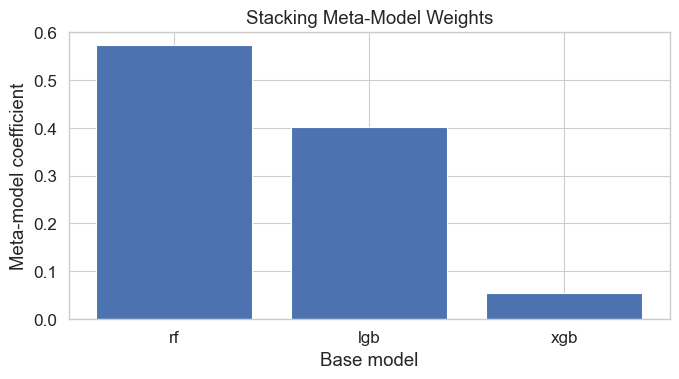

In [80]:
coef_df = pd.DataFrame({
    "Base_Model": oof_train.columns,
    "Coefficient": meta_pos.coef_
}).sort_values("Coefficient", ascending=False)

print(coef_df)

plt.figure(figsize=(7,4))
plt.bar(coef_df["Base_Model"], coef_df["Coefficient"])
plt.xlabel("Base model")
plt.ylabel("Meta-model coefficient")
plt.title("Stacking Meta-Model Weights")
plt.tight_layout()
plt.show()